# Step 2 - Prep Data for Modeling

This notebook will clean and prepare the data for modeling. It exports a new clean version of the original dataset. 

In [13]:
# Import the paackages used in this notebook
import pandas as pd 
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
# Read in the data from Coursera 
bitcoin_df = pd.read_csv("data/bitcoin.csv")

## Remove missing/bad data

In [10]:
# Remove rows where btc_trade_volume is null
bitcoin_df = bitcoin_df.dropna(subset=['btc_trade_volume'])

In [11]:
# Ensure there are no more null values in the dataset
bitcoin_df.isnull().sum()

Date                                                   0
btc_market_price                                       0
btc_total_bitcoins                                     0
btc_market_cap                                         0
btc_trade_volume                                       0
btc_blocks_size                                        0
btc_avg_block_size                                     0
btc_n_orphaned_blocks                                  0
btc_n_transactions_per_block                           0
btc_median_confirmation_time                           0
btc_hash_rate                                          0
btc_difficulty                                         0
btc_miners_revenue                                     0
btc_transaction_fees                                   0
btc_cost_per_transaction_percent                       0
btc_cost_per_transaction                               0
btc_n_unique_addresses                                 0
btc_n_transactions             

In [12]:
# Remove 0 values from the following columns based on reasoning in data exploration step 
print("shape before removing rows: ", bitcoin_df.shape)
cols_to_check = [
    'btc_market_price',
    'btc_market_cap',
    'btc_trade_volume',
    'btc_blocks_size',
    'btc_median_confirmation_time',
    'btc_miners_revenue',
    'btc_transaction_fees',
    'btc_cost_per_transaction',
    'btc_estimated_transaction_volume_usd'
]

bitcoin_df = bitcoin_df[(bitcoin_df[cols_to_check] != 0).all(axis=1)]
print("shape after removing rows: ", bitcoin_df.shape)

shape before removing rows:  (2899, 24)
shape after removing rows:  (2258, 24)


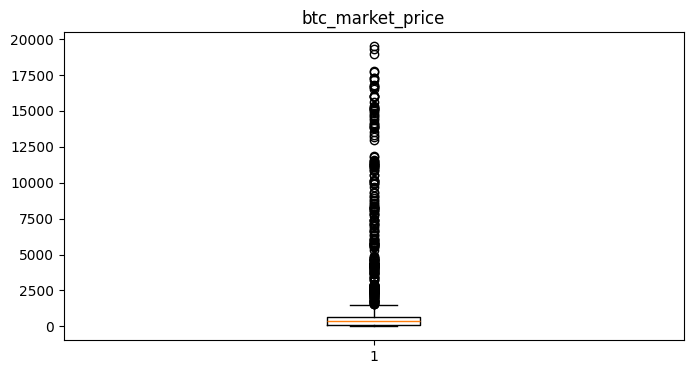

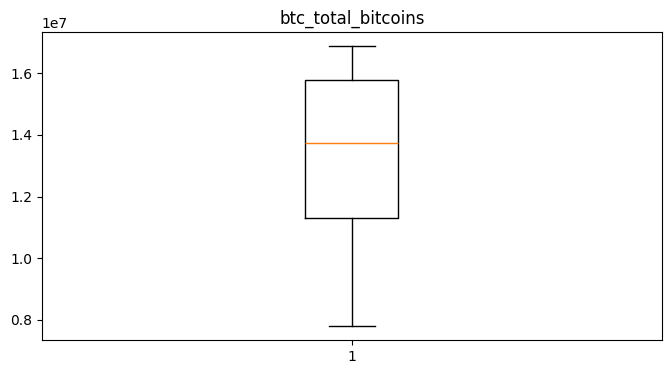

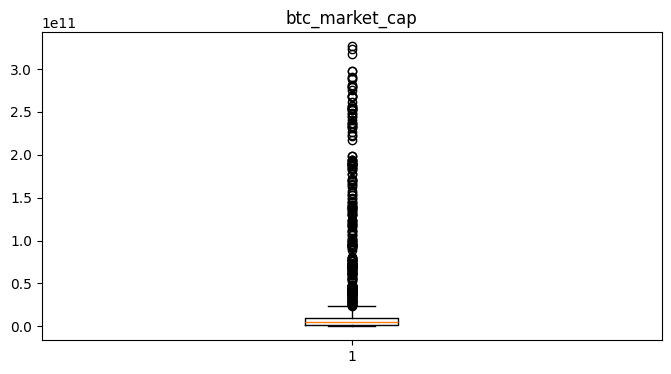

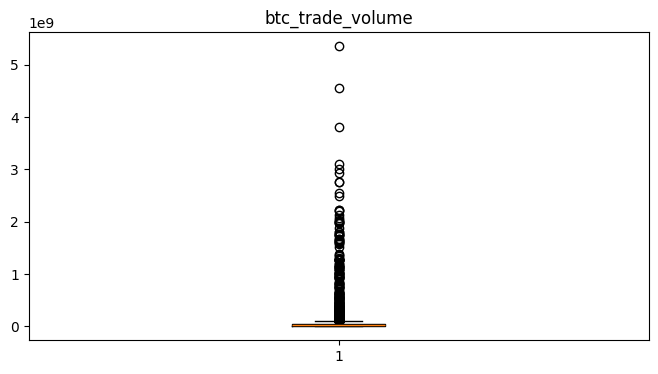

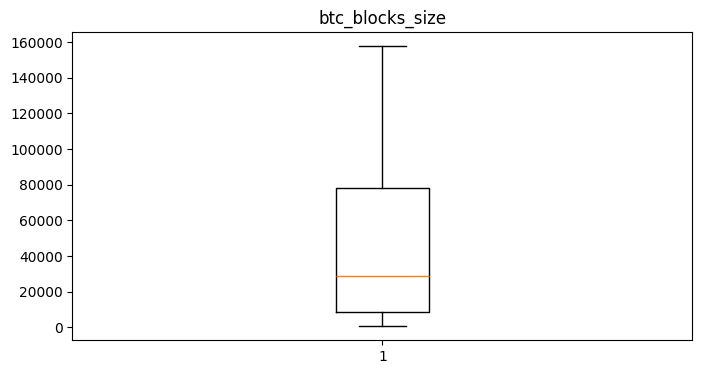

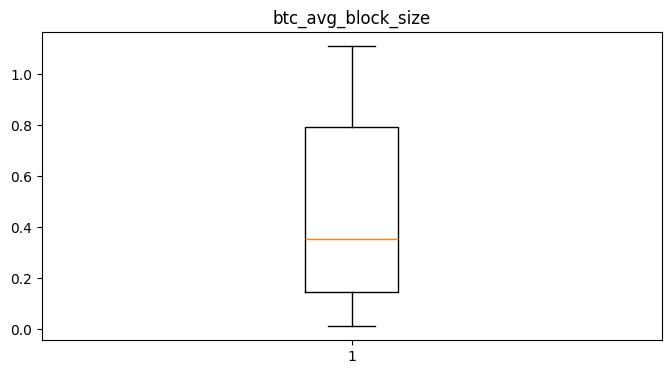

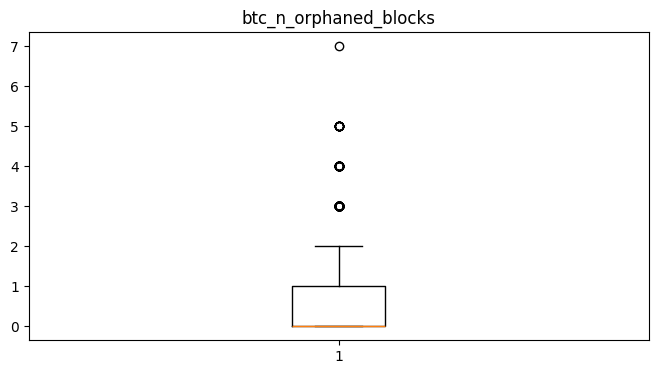

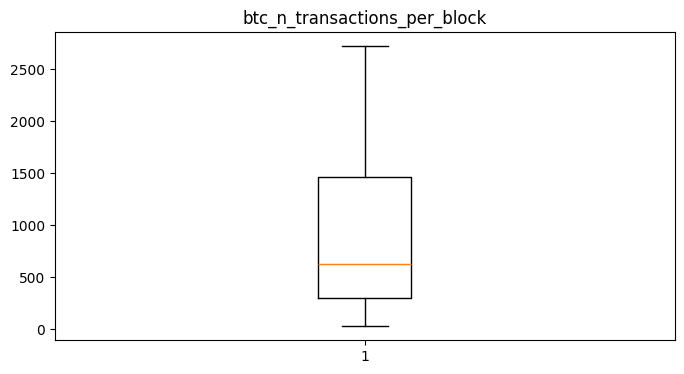

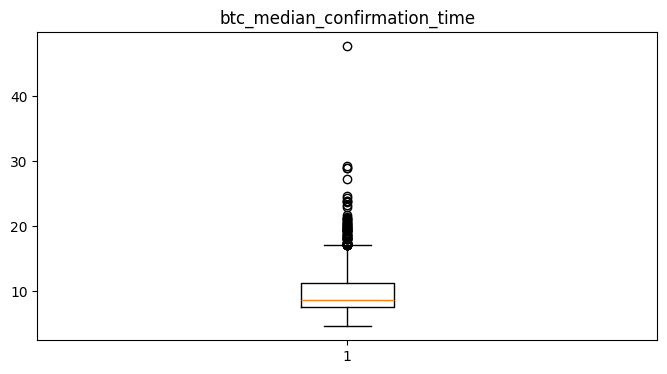

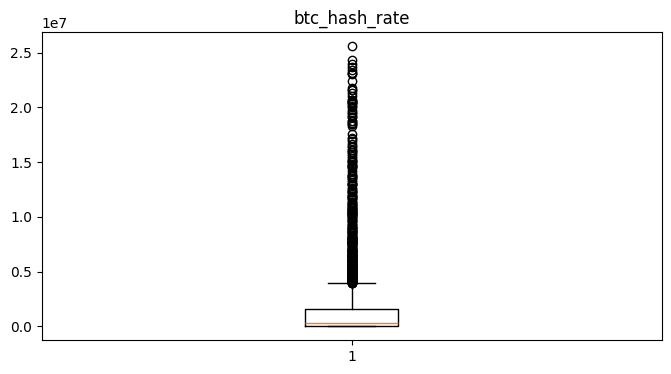

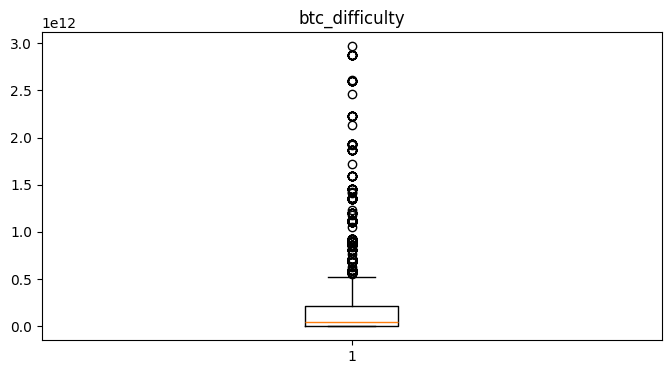

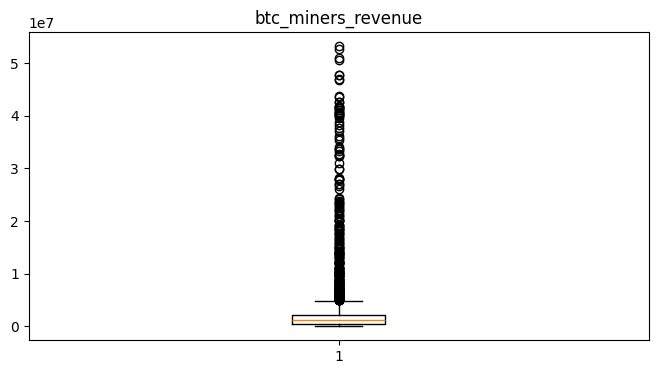

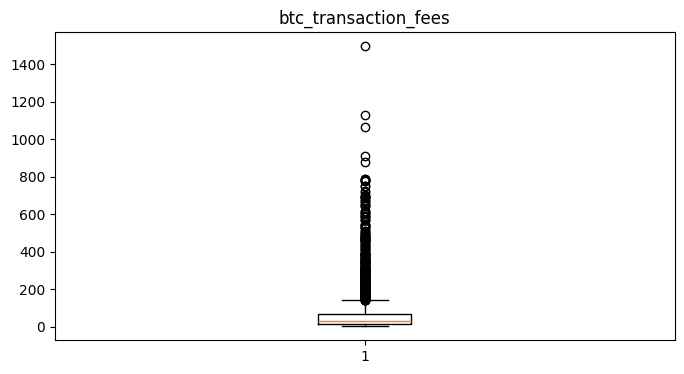

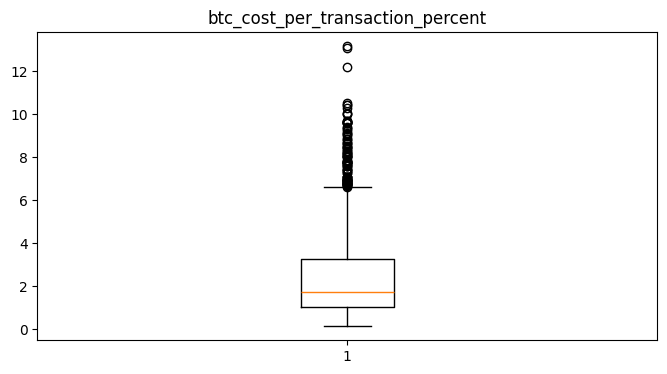

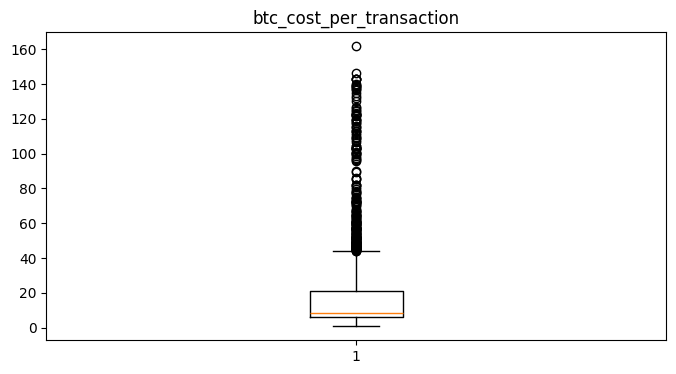

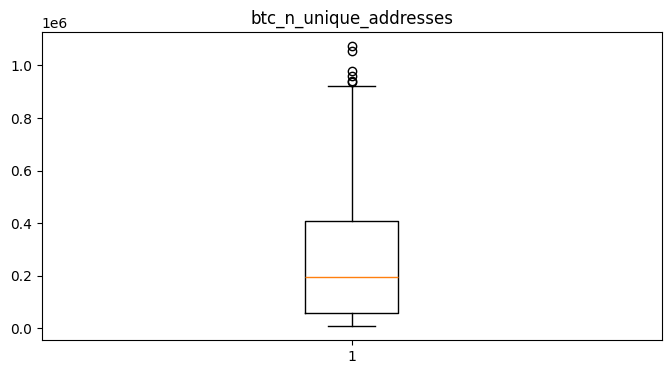

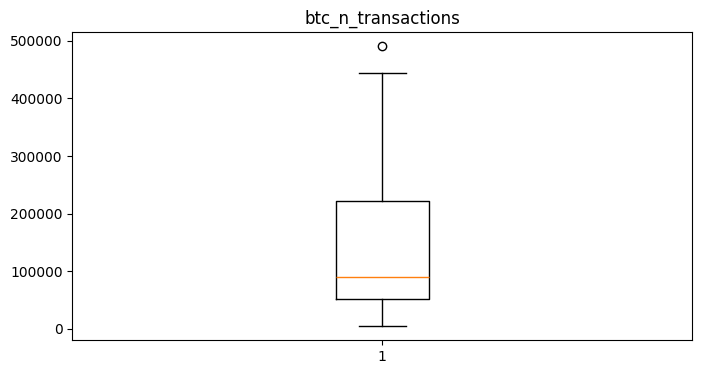

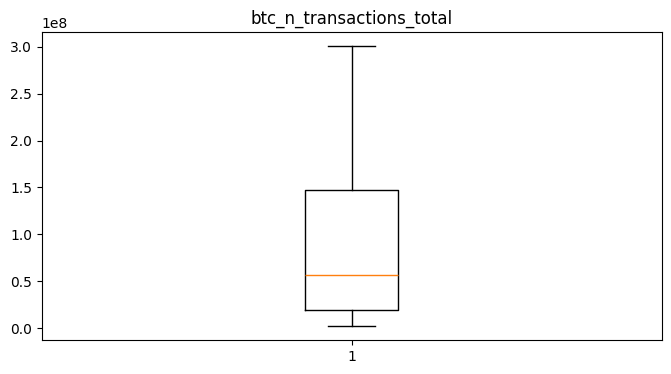

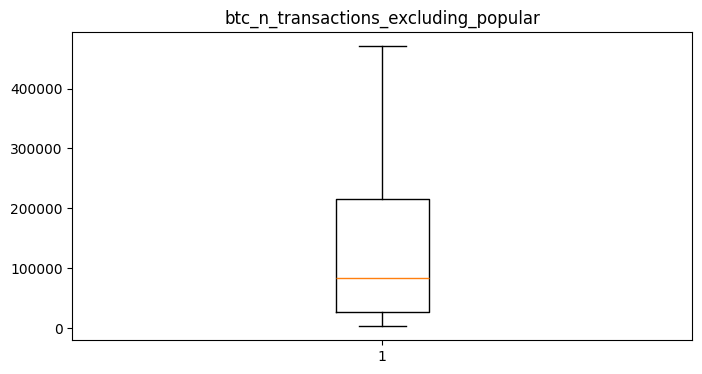

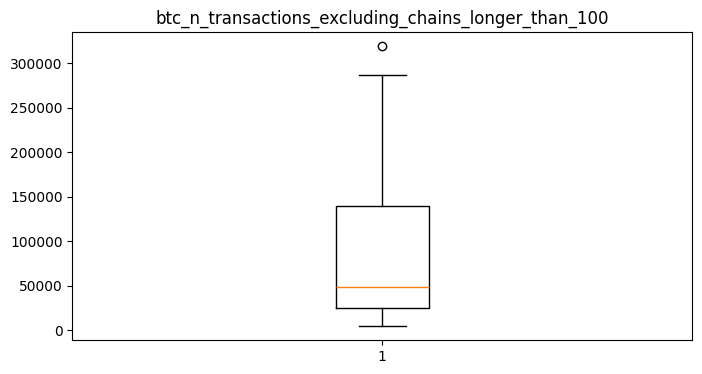

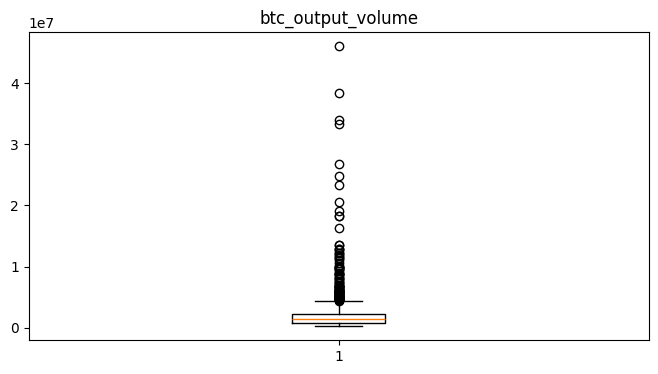

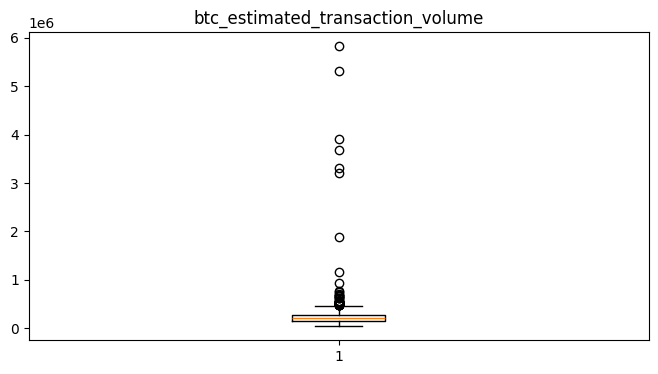

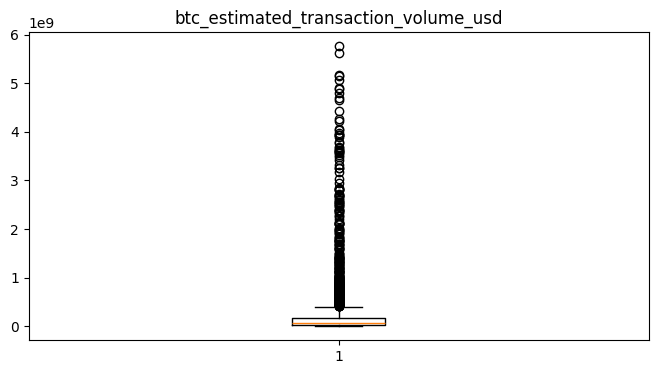

In [19]:
# Create box plots to identify extreme outliers
num_cols = bitcoin_df.select_dtypes(include="number")
for col in num_cols.columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(bitcoin_df[col])
    plt.title(col)
    plt.show()

Looking at these boxplots, any outliers make sense. Bitcoin itself is extremely volatile so it's not surprising we'd have volatile data points. 

In [20]:
# export the cleaned data to use in modeling
bitcoin_df.to_csv("data/bitcoin_clean.csv")